### Task 1: Compute Pearson and Spearman Correlations

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import seaborn as sns

# Load dataset
df = sns.load_dataset("penguins")

# Drop missing values
df = df.dropna()

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Compute Pearson and Spearman matrices
pearson_matrix = df[numeric_cols].corr(method='pearson')
spearman_matrix = df[numeric_cols].corr(method='spearman')

print("=== Pearson Correlation Matrix ===")
print(pearson_matrix)

print("\n=== Spearman Correlation Matrix ===")
print(spearman_matrix)

# Create summary table with p-values
results = []

for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]

        pearson_r, pearson_p = pearsonr(df[col1], df[col2])
        spearman_r, spearman_p = spearmanr(df[col1], df[col2])

        results.append({
            "Feature 1": col1,
            "Feature 2": col2,
            "Pearson r": round(pearson_r, 4),
            "Pearson p": round(pearson_p, 6),
            "Spearman ρ": round(spearman_r, 4),
            "Spearman p": round(spearman_p, 6)
        })

summary_df = pd.DataFrame(results)

# Sort by strongest correlation
summary_df = summary_df.sort_values(by="Pearson r", key=abs, ascending=False)

print("\n=== Summary Table ===")
print(summary_df)

=== Pearson Correlation Matrix ===
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  

=== Spearman Correlation Matrix ===
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.213859           0.669754   
bill_depth_mm           -0.213859       1.000000          -0.517317   
flipper_length_mm        0.669754      -0.517317           1.000000   
body_mass_g              0.576480      -0.429283           0.840390   

                   body_mass_g  
bill_length_mm    

### Task 1: Correlation Analysis

#### Which pairs show the strongest linear relationships?

The strongest linear relationship is between flipper_length_mm and body_mass_g with a Pearson correlation of 0.873. This indicates a very strong positive relationship, meaning that penguins with longer flippers tend to have higher body mass.

Another strong relationship is between bill_length_mm and flipper_length_mm (r ≈ 0.653), followed by bill_length_mm and body_mass_g (r ≈ 0.589). These also show moderate to strong positive linear relationships.

On the negative side, bill_depth_mm has a moderately strong negative correlation with flipper_length_mm (r ≈ -0.578), meaning deeper bills are associated with shorter flippers.

---

#### Are there any pairs where Pearson and Spearman disagree noticeably? What might cause that?

Overall, Pearson and Spearman correlations are quite similar across all feature pairs, which suggests that most relationships are approximately linear.

However, small differences can still be observed. For example, the correlation between flipper_length_mm and body_mass_g is slightly lower in Spearman (0.840) than Pearson (0.873). Similarly, bill_depth_mm relationships show slightly weaker Spearman values.

These differences may be caused by minor non-linear patterns or the presence of outliers in the data. Since Pearson measures strictly linear relationships and is sensitive to extreme values, while Spearman is based on ranks and captures monotonic relationships, such small deviations indicate that the relationships are mostly linear but not perfectly so.

Additionally, all p-values are extremely close to zero, indicating that these correlations are statistically significant and unlikely to have occurred by chance.

### Task 2: Build a Correlation Heatmap

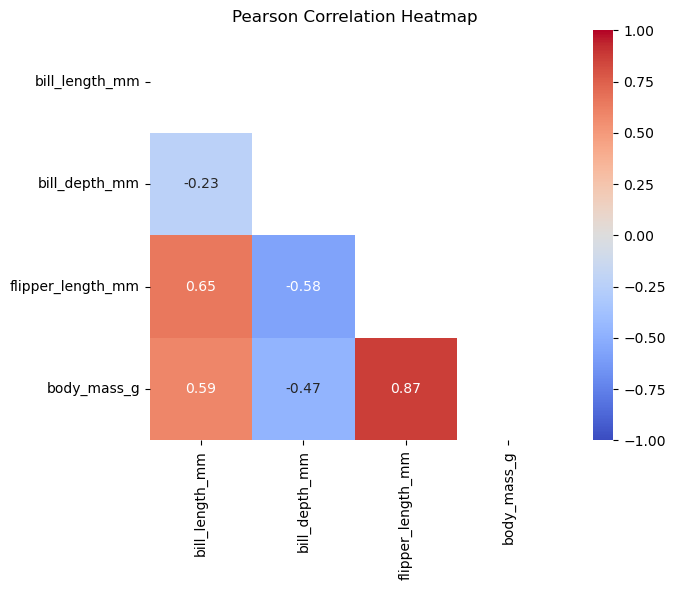

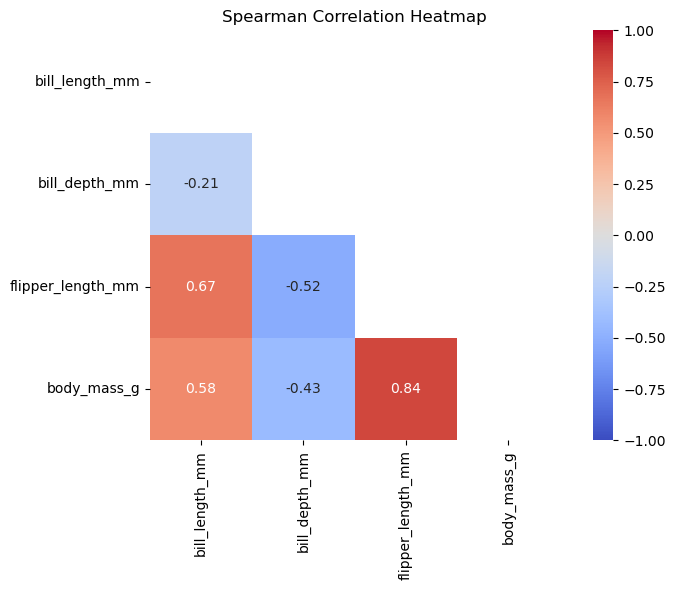

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pearson and Spearman matrices (reuse from Task 1 if already defined)
pearson_matrix = df[numeric_cols].corr(method='pearson')
spearman_matrix = df[numeric_cols].corr(method='spearman')

# Create mask for upper triangle
mask = np.triu(np.ones_like(pearson_matrix, dtype=bool))

# ---- Pearson Heatmap ----
plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---- Spearman Heatmap ----
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

### Task 2: Correlation Heatmaps

#### Where do Pearson and Spearman heatmaps agree?

The Pearson and Spearman heatmaps show very similar patterns across all feature pairs. The strongest positive relationship appears between flipper_length_mm and body_mass_g in both heatmaps (Pearson ≈ 0.87, Spearman ≈ 0.84), indicating a very strong and consistent association.

Other relationships, such as bill_length_mm with flipper_length_mm and body_mass_g, are also similarly strong in both heatmaps. Additionally, negative relationships like bill_depth_mm with flipper_length_mm and body_mass_g are consistent in both matrices.

This strong agreement suggests that most relationships in the dataset are both linear and monotonic.

---

#### Where do they differ, and what does that tell you?

There are small differences in correlation values between Pearson and Spearman. For example, the correlation between flipper_length_mm and body_mass_g decreases slightly from 0.87 (Pearson) to 0.84 (Spearman). Similarly, negative correlations such as bill_depth_mm and flipper_length_mm are slightly weaker in Spearman.

These differences indicate that while the relationships are mostly linear, there may be slight non-linear patterns or minor influence of outliers in the data. Since Spearman uses rank-based correlation, it is less sensitive to extreme values.

Overall, the differences are small, confirming that the relationships in the dataset are stable, strong, and mostly linear.

The heatmaps also make it easier to quickly identify which feature pairs are strongly related and which ones have weak relationships close to zero.

### Task 3: Scatterplot Analysis of Key Pairs

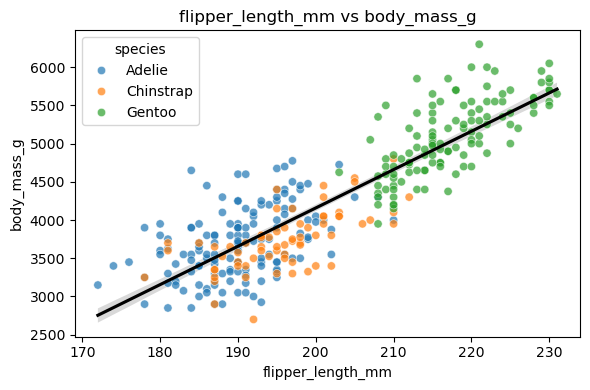

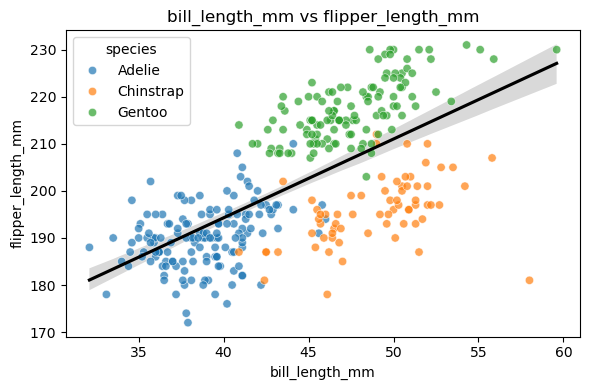

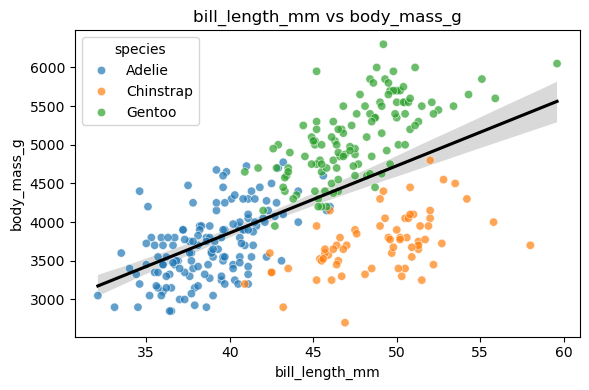

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 3 strongest pairs (based on your results)
pairs = [
    ("flipper_length_mm", "body_mass_g"),
    ("bill_length_mm", "flipper_length_mm"),
    ("bill_length_mm", "body_mass_g")
]

# Categorical column (penguins dataset)
hue_col = "species"

for x, y in pairs:
    plt.figure(figsize=(6, 4))
    
    sns.regplot(data=df, x=x, y=y, scatter=False, color="black")
    
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue=hue_col,
        alpha=0.7
    )
    
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()

### Task 3: Scatterplot Analysis of Key Pairs

#### Does the regression line capture the actual pattern well?

The regression line captures the overall trend well for all three feature pairs. In particular, the relationship between flipper_length_mm and body_mass_g shows a very strong positive linear pattern, and the regression line follows the general direction of the data closely.

However, the scatterplots also show that the observations are grouped into visible clusters rather than being evenly spread around the regression line. This suggests that the overall relationship is influenced by subgroup structure in the dataset.

---

#### Do subgroups show different slopes or intercepts?

Yes, the subgroups (species) show clear differences in intercepts and slightly different patterns.

In all three plots, each species forms its own cluster:
- Adelie penguins tend to have smaller flipper lengths and lower body mass
- Chinstrap penguins generally fall in the middle range
- Gentoo penguins tend to have the largest values for these features

These clusters show that for similar x values, the y values may still differ depending on species. This suggests that species has an important effect on the relationships between variables.

---

#### Interpretation

The clear subgroup clustering suggests that species is an important grouping and confounding variable in this dataset.

The overall regression line summarizes the general relationship, but it can hide meaningful differences between species. This shows why subgroup-level analysis is important when interpreting correlations and scatterplots.

The pattern may indicate the possibility of Simpson’s paradox or other aggregation effects, where combined data can hide or distort subgroup behavior. Therefore, it is important to examine both the full dataset and subgroup patterns before drawing conclusions.